# Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
working_dir = os.getcwd()
FOLDER_NAME = os.path.basename(working_dir)
FILE_NAME = 'macd_xlstm'

STOCK = 'BTC'
FREQ = '1h'

# TRADE_PRICE = 'close'
TRADE_PRICE = 'open'
# TRADE_PRICE = 'low'
# TRADE_PRICE = 'high'



SEQ_LENGTH = 28
BATCH_SIZE = 8

TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)

In [3]:
os.chdir(os.path.join('..','data'))
df = pd.read_csv(f'{STOCK}USD_2023_2024.csv', index_col='Gmt time')
df.index = pd.to_datetime(df.index, format="%d.%m.%Y %H:%M:%S.%f", errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})

In [4]:
os.chdir('..')
from utils.utils import CreateTimeFrames
df = CreateTimeFrames(df, [FREQ])[FREQ]
df = df.iloc[-4050:,:]

In [5]:
close = df[f'{TRADE_PRICE}'].to_numpy(dtype=np.int32)
print(f'There are {close.size} {TRADE_PRICE} prices.')

There are 4050 open prices.


In [6]:
train = close[:int(np.ceil(TRAIN_SPLIT*len(close)))]
val = close[int(np.ceil(TRAIN_SPLIT*len(close))): int(np.ceil( (TRAIN_SPLIT+VAL_SPLIT)*len(close) ))]
test = close[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(close))):]
assert len(train) + len(val) + len(test) == len(df), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train.size}, val size:{val.size}, test size:{test.size}.')


train size:2835, val size:405, test size:810.


In [7]:
os.chdir('denoise')
from dwt import *
os.chdir(os.path.join('..', 'macdxlstm'))

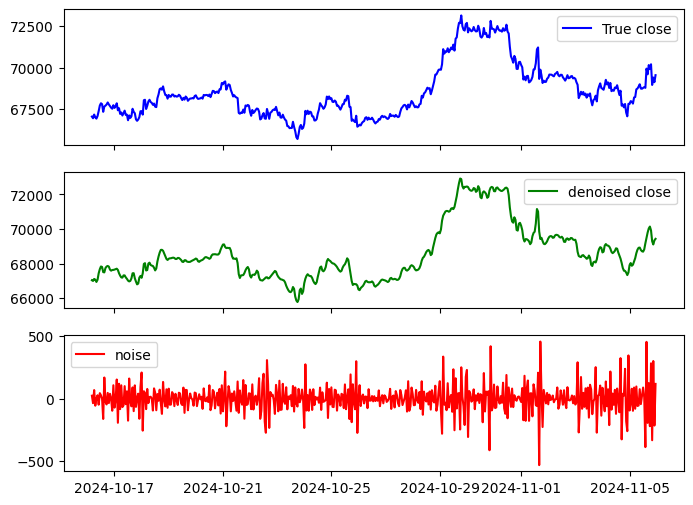

In [8]:
df[f'smoothed_data_{TRADE_PRICE}'] = wavelet_denoising(df[f'{TRADE_PRICE}'])
df['noise'] = df[f'{TRADE_PRICE}'] - df[f'smoothed_data_{TRADE_PRICE}']

import matplotlib.pyplot as plt
# fig = plt.figure(figsize=(8,6))
fig, axs = plt.subplots(3,1, figsize=(8,6), sharex=True)

axs[0].plot(df[f'{TRADE_PRICE}'].iloc[-500:], color = 'blue', label='True close')
axs[0].legend()

axs[1].plot(df[f'smoothed_data_{TRADE_PRICE}'].iloc[-500:], color = 'green', label='denoised close')
axs[1].legend()

axs[2].plot(df['noise'].iloc[-500:], color = 'red', label = 'noise')
axs[2].legend()


# MACD optimization

In [9]:
os.chdir(os.path.join('..', 'genetic'))
from classes import KalmanFilterEM, MACD_GA_v2
os.chdir(os.path.join('..', 'macdxlstm'))


## Create sequence

In [10]:
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences, dtype=np.int64)

sequences = create_sequences(df[f'smoothed_data_{TRADE_PRICE}'].values, SEQ_LENGTH)
print(f'Created {len(sequences)} sequences of length {SEQ_LENGTH}.')

Created 4023 sequences of length 28.


In [11]:
def optimize_macd(df, real_price = f'{TRADE_PRICE}', signal_price=f'smoothed_data_{TRADE_PRICE}'):

    # Initialize the optimizer
    optimizer = MACD_GA_v2(df_train=df, real_price = real_price, signal_price=signal_price)
    
    # Run the genetic algorithm
    optimizer.run_ga()
    
    # Get the best parameters
    best_params = optimizer.get_best_parameters()
    return best_params

In [ ]:
best_macd_coefficients = np.zeros((len(sequences), 3), dtype=np.int8)

for i, seq in enumerate(sequences):

    df_macd = pd.DataFrame({
        'seq':seq,
        f'{TRADE_PRICE}':df[f'{TRADE_PRICE}'][i:i+SEQ_LENGTH],
        f'smoothed_data_{TRADE_PRICE}': df[f'smoothed_data_{TRADE_PRICE}'][i:i+SEQ_LENGTH]
    })

    x = optimize_macd(df_macd, real_price=TRADE_PRICE, signal_price=f'smoothed_data_{TRADE_PRICE}')
    best_macd_coefficients[i,0] = x.get('Fast EMA')
    best_macd_coefficients[i,1] = x.get('Slow EMA')
    best_macd_coefficients[i,2] = x.get('Signal Line')
    print(i)

In [ ]:
best_macd_coefficients.shape

In [11]:
path = f'./{SEQ_LENGTH}'

try:
    os.mkdir(path)
    print(f"Directory '{path}' created successfully.")
except FileExistsError:
    print(f"Directory '{path}' already exists.")
except Exception as e:
    print(f"An error occurred: {e}")

Directory './28' already exists.


In [15]:
# np.save(f'{SEQ_LENGTH}/best_macd_coefficients_{TRADE_PRICE}.npy', best_macd_coefficients)
# # np.load

In [12]:
os.getcwd()

'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\macdxlstm'

In [13]:
best_macd_coefficients = np.load(f'{SEQ_LENGTH}/best_macd_coefficients_{TRADE_PRICE}_{SEQ_LENGTH}.npy')

In [14]:
def calculate_ema(values, period):
    return pd.Series(values).ewm(span=period, adjust=False).mean().values

def calculate_macd(sequence, fast_period, slow_period, signal_period):
    # calculate macd things for a sequence.
    macd_line = calculate_ema(sequence, fast_period)-calculate_ema(sequence, slow_period)
    signal_line = calculate_ema(macd_line, signal_period)
    histogram = macd_line-signal_line
    return macd_line, signal_line, histogram



In [15]:
macd_lines = []
signal_lines = []
histograms = []

In [16]:
for i, seq in enumerate(sequences):
    f,s,h = best_macd_coefficients[i]
    macd_line, signal_line, histogram = calculate_macd(seq, fast_period=f,slow_period=s,signal_period=h)
    macd_lines.append(macd_line)
    signal_lines.append(signal_line)
    histograms.append(histogram)

macd_lines = np.array(macd_lines)
signal_lines = np.array(signal_lines)
histograms = np.array(histograms)

In [17]:
def label_sequence(macd_lines, signal_lines ):

    a, b = macd_lines.shape
    labels = np.zeros((a,b), dtype=np.int8)
    for i in range(0,a):
        # a = 3931
        for j in range(2, b):
            # b = 120

            if macd_lines[i,j] > signal_lines[i,j] and macd_lines[i, j-1]<=signal_lines[i, j-1]:
                labels[i, j] = 1 # Buy
            elif macd_lines[i,j] < signal_lines[i,j] and macd_lines[i, j-1] >=signal_lines[i,j-1]:
                labels[i,j] = -1 # Sell

    return labels

In [18]:
sequence_labels = label_sequence(macd_lines, signal_lines)
sequence_labels = np.array(sequence_labels)

In [19]:
def catch_the_best(df, sequences, seq_len=SEQ_LENGTH):
    the_best_values = np.zeros(len(df))
    s = len(df)-seq_len + 1
    for i in range(s):
        the_best_values[i] = sequences[i,-1]


    the_best_values[s-1:] = sequences[-1,:]
        # if i == s:
        #     the_best_values[i:] = sequences[i,:]
        # else:
        #     the_best_values[i] = sequences[i,-1]

    return the_best_values

In [20]:
data_labels = catch_the_best(df, sequence_labels)

In [21]:
num_buy = np.count_nonzero(data_labels==1)
print(f'num_buy is: {num_buy}.')

num_sell = np.count_nonzero(data_labels==-1)
print(f'num_sell is: {num_sell}.')

num_hold = np.count_nonzero(data_labels==0)
print(f'num_hold is: {num_hold}.')
assert num_buy+num_sell+num_hold == len(df), 'Some data are ignored.'

num_buy is: 484.
num_sell is: 499.
num_hold is: 3067.


In [22]:
def enforce_trade_sequence(data_labels):
    """
    Ensure that the sequence of Buy/Sell labels results in an equal number of Buy and Sell signals
    or one more Buy/Sell signal, adhering to trading rules.
    """
    corrected_labels = np.zeros_like(data_labels, dtype=np.int8)
    last_trade = 0  # 0 indicates no trade yet, 1 = Buy, -1 = Sell
    num_buy = 0
    num_sell = 0

    for i, label in enumerate(data_labels):
        if label == 1:  # Current signal is Buy
            if last_trade in [0, -1]:  # Valid only after Sell or no trade
                corrected_labels[i] = 1
                last_trade = 1
                num_buy += 1
            else:  # Invalid Buy; replace with Hold
                corrected_labels[i] = 0

        elif label == -1:  # Current signal is Sell
            if last_trade == 1:  # Valid only after Buy
                corrected_labels[i] = -1
                last_trade = -1
                num_sell += 1
            else:  # Invalid Sell; replace with Hold
                corrected_labels[i] = 0

        else:  # Current signal is Hold
            corrected_labels[i] = 0  # Always valid

    if last_trade == 1:
        corrected_labels[-1] = -1
        num_sell += 1

    return corrected_labels, num_buy, num_sell


In [23]:
# Correct the sequence to ensure valid trade rules
data_labels, final_num_buy, final_num_sell = enforce_trade_sequence(data_labels)

print(f"Final num_buy is: {final_num_buy}.")
print(f"Final num_sell is: {final_num_sell}.")
assert abs(final_num_buy - final_num_sell) <= 1, "Number of Buy and Sell trades must be equal or differ by one."


Final num_buy is: 375.
Final num_sell is: 375.


In [24]:
df['labels'] = data_labels

In [25]:
macd_line_new = catch_the_best(df,macd_lines)
signal_line_new = catch_the_best(df, signal_lines)
histogram_new = catch_the_best(df,histograms)

In [26]:
def replace_zeros_with_mean(arr):
    # Create a copy of the array to avoid modifying the original during iteration
    modified_array = arr.copy()
    
    # Iterate through the array starting from index 1 to len(arr) - 2
    for i in range(1, len(arr) - 1):
        if arr[i] == 0:
            # Calculate mean of previous and next elements
            mean_value = (arr[i - 1] + arr[i + 1]) / 2
            modified_array[i] = mean_value
            
    return modified_array

In [27]:
macd_lines.shape

(4023, 28)

In [28]:
macd_line_new = replace_zeros_with_mean(macd_line_new)
signal_line_new = replace_zeros_with_mean(signal_line_new)
histogram_new = replace_zeros_with_mean(histogram_new)

In [29]:
df['macd_line'] = macd_line_new
df['signal_line'] = signal_line_new
df['histogram'] = histogram_new

In [30]:
np.save(f'{SEQ_LENGTH}/macd_line_{SEQ_LENGTH}_{TRADE_PRICE}.npy',macd_line_new)
np.save(f'{SEQ_LENGTH}/signal_line_{SEQ_LENGTH}_{TRADE_PRICE}.npy', signal_line_new)
np.save(f'{SEQ_LENGTH}/histogram_{SEQ_LENGTH}_{TRADE_PRICE}.npy', histogram_new)


# Show me

In [ ]:
df

In [ ]:
plt.plot(df['macd_line'][:40], color = 'blue', label = 'MACD')
plt.plot(df['signal_line'][:40], color = 'red', label='Signal')
plt.legend()

In [ ]:
df.columns

## Feature inputs

In [37]:
x = df[['macd_line','signal_line', 'histogram']].copy()
y = df['labels'].copy

In [ ]:
x

## Create sequence of features

In [39]:
x_seq = create_sequences(x, SEQ_LENGTH)

## Encode output

In [40]:
y_enc = pd.get_dummies(df['labels'], prefix='y', drop_first=False)

In [ ]:
y_enc

In [ ]:
x_seq.shape

## step 6: Set output feature. 

In [43]:
y_enc_adjust = y_enc[:-1].to_numpy()
x_seq_adjust = x_seq[1:]

In [ ]:
print(f'y_enc_adjust.shape is: {y_enc_adjust.shape}')
print(f'x_seq_adjust.shape is: {x_seq_adjust.shape}')

In [ ]:
y_enc_adjust = y_enc_adjust[SEQ_LENGTH-1:]
print(f'y_enc_adjust.shape is: {y_enc_adjust.shape}')

# Split data set

In [ ]:
len(x_seq_adjust)

In [ ]:
train_x = x_seq_adjust[:int(np.floor(TRAIN_SPLIT*len(x_seq_adjust)))]
val_x= x_seq_adjust[int(np.ceil(TRAIN_SPLIT*len(x_seq_adjust))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(x_seq_adjust) ))]
test_x= x_seq_adjust[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(x_seq_adjust))):]
assert len(train_x) + len(val_x) + len(test_x) == len(x_seq_adjust), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train_x.shape[0]}, val size:{val_x.shape[0]}, test size:{test_x.shape[0]}.')


In [ ]:
train_y = y_enc_adjust[:int(np.floor(TRAIN_SPLIT*len(x_seq_adjust)))]
val_y= y_enc_adjust[int(np.ceil(TRAIN_SPLIT*len(x_seq_adjust))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(x_seq_adjust) ))]
test_y= y_enc_adjust[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(x_seq_adjust))):]
assert len(train_y) + len(val_y) + len(test_y) == len(y_enc_adjust), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train_y.shape[0]}, val size:{val_y.shape[0]}, test size:{test_y.shape[0]}.')


In [53]:
import torch

In [54]:
def create_dataloader(x, y, batch_size = BATCH_SIZE, shuffle=False):
  dataset = torch.utils.data.TensorDataset(x, y)
  dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
  return dataloader

In [58]:
train_x = torch.tensor(train_x, dtype=torch.float32)
train_y = torch.tensor(train_y, dtype=torch.float32)
val_x = torch.tensor(val_x, dtype=torch.float32)
val_y = torch.tensor(val_y, dtype=torch.float32)
test_x = torch.tensor(test_x, dtype=torch.float32)
test_y = torch.tensor(test_y, dtype=torch.float32)

In [59]:
train_loader = create_dataloader(train_x, train_y)
val_loader = create_dataloader(val_x, val_y)
test_loader = create_dataloader(test_x, test_y)

In [60]:
torch.save(train_loader, f'{SEQ_LENGTH}/train_loader.pt')
torch.save(val_loader, f'{SEQ_LENGTH}/val_loader.pt')
torch.save(test_loader, f'{SEQ_LENGTH}/test_loader.pt')


In [ ]:
torch.save(val_x, f'{SEQ_LENGTH}/val_x.pt')
torch.save(test_x, f'{SEQ_LENGTH}/test_x.pt')


In [63]:
torch.save(train_x, f'{SEQ_LENGTH}/train_x.pt')
torch.save(train_y, f'{SEQ_LENGTH}/train_y.pt')
torch.save(val_y, f'{SEQ_LENGTH}/val_y.pt')
torch.save(test_y, f'{SEQ_LENGTH}/test_y.pt')
